# Receta ejecutable: del CSV a las predicciones

**Pablo Hidalgo Delgado y Marcos Caballero Cortés · UC3M, Redes de Neuronas**

Este cuaderno completa el borrador que terminaba en la codificación de etiquetas.
El preprocesamiento, el entrenamiento, la evaluación y la inferencia utilizan
las mismas funciones probadas del ejecutable. Para consultar los fundamentos y las
limitaciones, véase `P2.1_RRNN.ipynb`.

Ejecutar desde la raíz después de instalar `requirements-dev.txt`.


In [1]:
from pathlib import Path
import json
import tempfile
import pandas as pd
from IPython.display import display, Image
from transport.data import load_data, partition, SensorScaler
from transport.pipeline import TrainConfig, run_experiment, predict

DATA = Path("dataRRNN2.csv")
if not DATA.exists():
    raise RuntimeError("Abra el cuaderno desde la raíz del repositorio.")
frame = load_data(DATA)
print(f"Muestras: {len(frame):,}; sensores: {frame.shape[1] - 3}")


Muestras: 29,151; sensores: 20


## Partición y normalización

Se reserva aproximadamente un tercio de las trayectorias para prueba. El 20 % de
las trayectorias restantes se destina a validación. Las proporciones por fila
pueden variar porque las trayectorias tienen longitudes distintas.

No se comparte ninguna trayectoria entre conjuntos. Sí pueden coincidir usuarios:
estos resultados no miden la generalización a personas nuevas. El ejecutable también
ofrece `--split user` para evaluar ese caso y `--split row` para comparar con la
partición estratificada de la práctica original.

La media y la desviación se calculan exclusivamente con el conjunto de entrenamiento.
Una variable constante se transforma en cero. La etiqueta se conserva como entero
de 0 a 4 para usar entropía cruzada categórica dispersa.


In [2]:
parts = partition(frame, seed=42, strategy="track")
display(pd.Series({name: len(rows) for name, rows in parts.items()}, name="Filas"))
scaler = SensorScaler.fit(frame.iloc[parts["train"]])
train = scaler.transform(frame.iloc[parts["train"]])
validation = scaler.transform(frame.iloc[parts["validation"]])
test = scaler.transform(frame.iloc[parts["test"]])
print("Formas:", train.shape, validation.shape, test.shape)
print("Máxima media absoluta del train normalizado:", abs(train.mean(axis=0)).max())


train         15264
validation     4088
test           9799
Name: Filas, dtype: int64

Formas: (15264, 20) (4088, 20) (9799, 20)
Máxima media absoluta del train normalizado: 2.0493001e-08


## Entrenamiento y selección

Se comparan dos redes densas de 64 y 32 neuronas con ReLU y salida softmax de cinco
clases: una sin ponderación y otra con pesos de clase calculados solo sobre train.
Adam utiliza un paso de 0,001. Early stopping observa la pérdida de validación,
con paciencia 10 y un máximo de 80 épocas. Se restauran los mejores pesos.

La red se elige por **F1 macro de validación**, antes de consultar el test.
Una clase mayoritaria y una regresión logística ponderada sirven de referencias.


In [3]:
RETRAIN = False
result_dir = Path("results/track-42")
if RETRAIN:
    # Cada ejecución utiliza una carpeta nueva y conserva las anteriores.
    Path("runs").mkdir(exist_ok=True)
    result_dir = Path(tempfile.mkdtemp(prefix="notebook-", dir="runs")) / "experiment"
    report = run_experiment(DATA, result_dir, TrainConfig())
else:
    report = json.loads((result_dir / "metrics.json").read_text(encoding="utf-8"))

display(pd.DataFrame({name: {
    "F1 macro validación": value["validation"]["macro_f1"],
    "Épocas": value["epochs_run"],
} for name, value in report["candidates"].items()}).T)
print("Modelo elegido:", report["selected_model"])


,F1 macro validación,Épocas
MLP,0.838500,37.0
MLP ponderado,0.826848,31.0


Modelo elegido: MLP


,Accuracy,F1 macro
Clase mayoritaria,0.374732,0.109034
Regresión logística,0.773446,0.736110
MLP,0.834677,0.804543


,precision,recall,f1-score,support
Andando,0.846630,0.930556,0.886611,3672.000000
Bicicleta,0.862451,0.737047,0.794833,1795.000000
Autobús,0.812390,0.847000,0.829334,2183.000000
Coche,0.866856,0.732934,0.794289,1670.000000
Metro,0.676525,0.764092,0.717647,479.000000
accuracy,0.834677,0.834677,0.834677,0.834677
macro avg,0.812970,0.802326,0.804543,9799.000000
weighted avg,0.837032,0.834677,0.833046,9799.000000


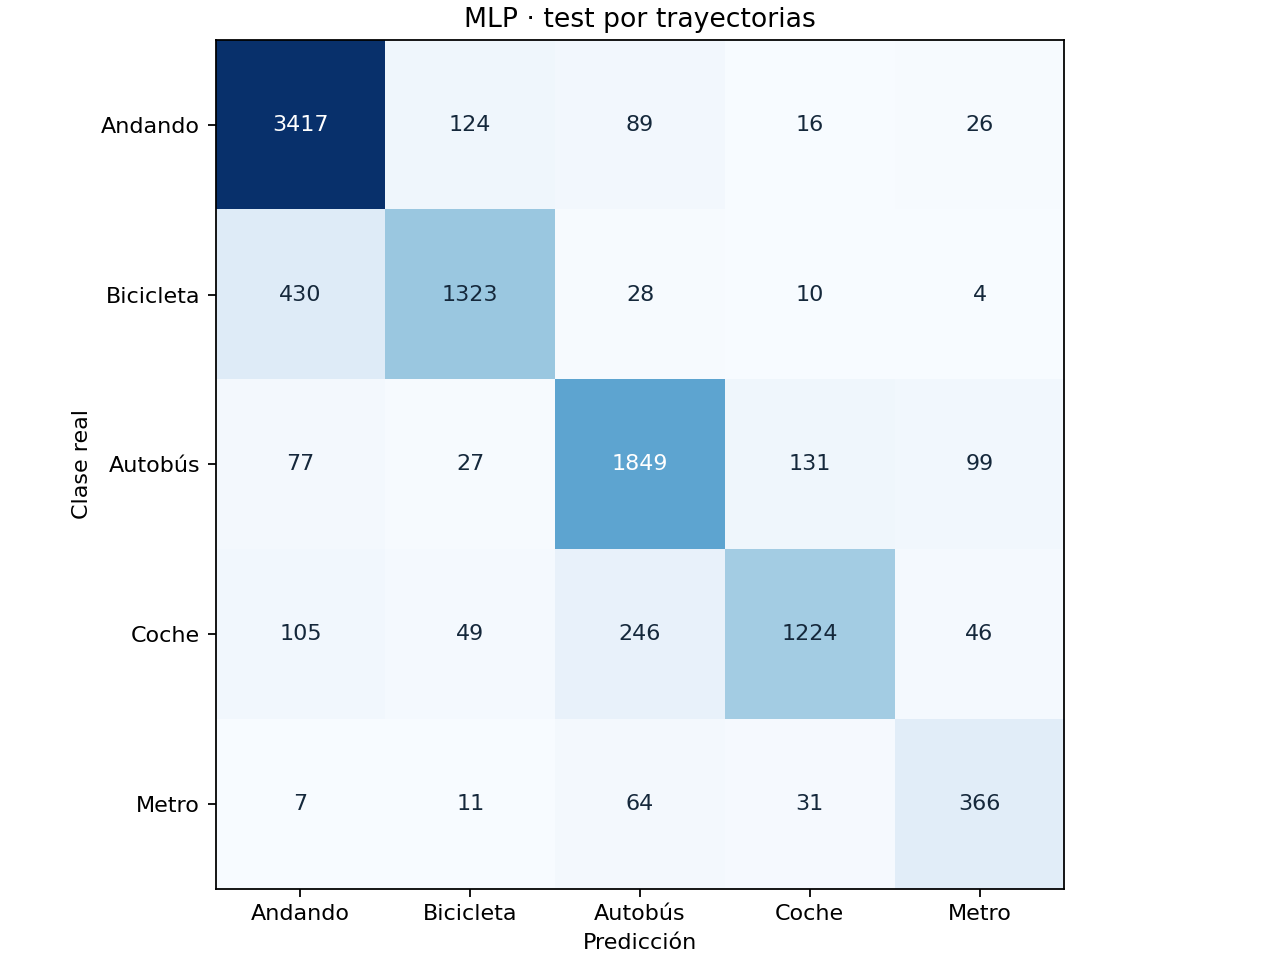

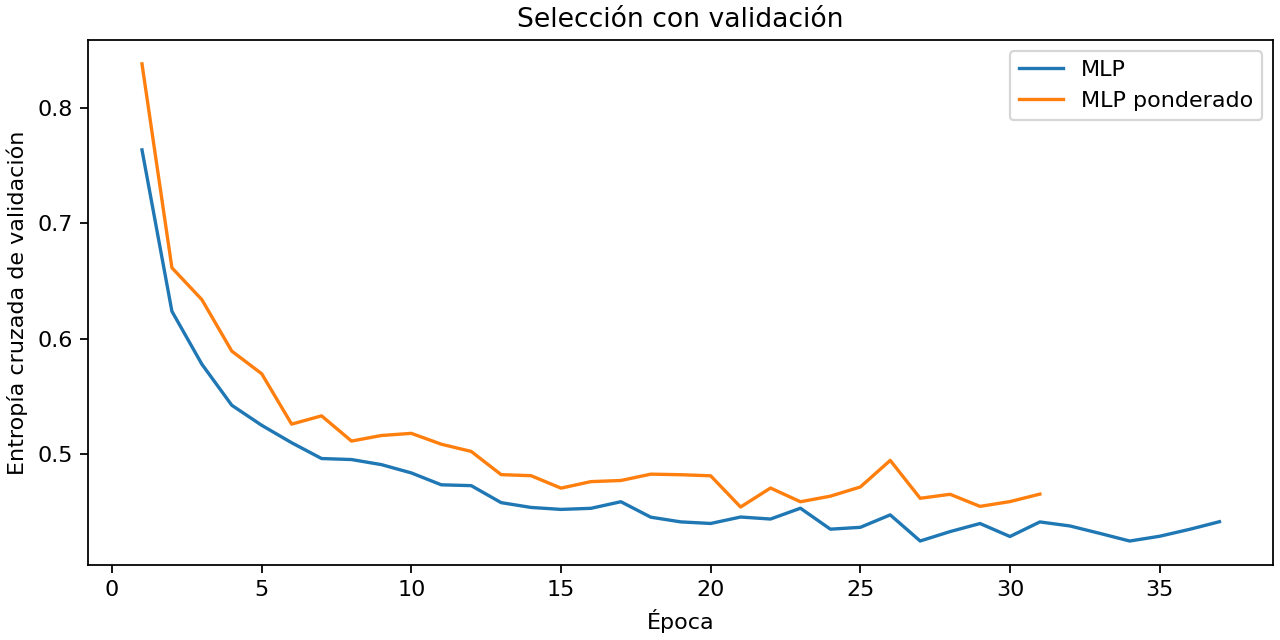

In [4]:
display(pd.DataFrame({name: {
    "Accuracy": value["accuracy"], "F1 macro": value["macro_f1"],
} for name, value in report["test"].items()}).T)
display(pd.DataFrame(report["test"][report["selected_model"]]["per_class"]).T)
display(Image(filename=str(result_dir / "confusion_matrix.png")))
display(Image(filename=str(result_dir / "validation_loss.png")))


In [5]:
# Reutilizamos el modelo guardado: no se entrena con estas filas de test.
stored_parts = json.loads((result_dir / "splits.json").read_text())
Path("runs").mkdir(exist_ok=True)
sample_path = Path("runs/held_out_example.csv")
frame.iloc[stored_parts["test"][:10]].drop(columns="label").to_csv(sample_path, index=False)
predictions = predict(result_dir, sample_path, "runs/example_predictions.csv")
display(predictions)


,label,class,p0,p1,p2,p3,p4
0,0,Andando,9.025283e-01,8.721608e-02,0.002375,0.007876,4.216135e-06
1,0,Andando,9.952071e-01,1.957607e-03,0.000049,0.002786,1.490376e-09
2,0,Andando,9.463356e-01,5.281077e-02,0.000010,0.000844,4.713964e-13
3,0,Andando,8.290288e-01,6.074459e-02,0.048836,0.061385,5.094681e-06
4,0,Andando,8.596610e-01,1.110463e-01,0.000715,0.028578,4.660874e-11
5,2,Autobús,3.532553e-05,2.743929e-03,0.690469,0.233701,7.305078e-02
6,2,Autobús,1.425369e-04,5.045547e-03,0.967959,0.014929,1.192352e-02
7,3,Coche,3.680067e-08,6.044990e-06,0.001606,0.998316,7.231288e-05
8,3,Coche,4.335553e-12,1.421537e-09,0.000418,0.998850,7.322684e-04
9,2,Autobús,3.848362e-03,5.043709e-03,0.724374,0.105540,1.611948e-01


## Interpretación

La ejecución publicada obtuvo **83,47 % de accuracy y 0,8045 de F1 macro** en 9.799
filas de test. La regresión logística obtuvo 0,7361 de F1 macro y predecir siempre
la clase mayoritaria obtuvo 0,1090. La red sin ponderación superó a la ponderada en
validación; por ello se seleccionó antes de la evaluación final.

El desbalanceo hace necesario consultar el F1 de cada clase y la matriz de confusión.
Una única partición y semilla no bastan para estimar la variabilidad del rendimiento.
Las cifras de esta ejecución no se atribuyen a la entrega original: corresponden
al pipeline reproducible que se incluye en este repositorio.
